# Markov-Switching AR Model on Cointegrated Pair Spread

This notebook:
1. Downloads daily price data for a cointegrated pair from Yahoo Finance
2. Computes and tests the spread
3. Fits a **3-regime Markov-Switching AR model** (each regime = low / mid / high spread)
4. Simulates new synthetic spread paths from the fitted model
5. Visualises everything

In [1]:
# ── 0. Imports ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf

from scipy import stats
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression

np.random.seed(42)
sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

print('All imports OK')

All imports OK


## 1  Download price data

Default pair: **KO / PEP** (Coca-Cola vs PepsiCo) — a textbook cointegrated pair.  
Change `TICKER_A`, `TICKER_B`, or the date range to use your own pair.

In [2]:
# ── 1. Configuration ────────────────────────────────────────────────────────
TICKER_A   = 'KO'
TICKER_B   = 'PEP'
START_DATE = '2015-01-01'
END_DATE   = '2024-12-31'

# AR order used inside each Markov regime
AR_ORDER   = 2
# Number of synthetic paths to generate
N_PATHS    = 5
# Length of each synthetic path (trading days)
N_STEPS    = 504   # ~2 years
# Burn-in steps discarded at the start of each simulated path
BURN_IN    = 200

# ── Download ────────────────────────────────────────────────────────────────
raw = yf.download([TICKER_A, TICKER_B], start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)

prices = raw['Close'][[TICKER_A, TICKER_B]].dropna()
print(f'Downloaded {len(prices)} daily rows  ({prices.index[0].date()} → {prices.index[-1].date()})')
prices.tail(3)

Downloaded 2515 daily rows  (2015-01-02 → 2024-12-30)


Ticker,KO,PEP
Date,,
2024-12-26,60.361835,145.284378
2024-12-27,60.246071,145.713242
2024-12-30,59.840889,144.598190


## 2  Compute the spread & test cointegration

The spread is defined as the OLS residual:
$$\text{spread}_t = P^A_t - \hat{\beta}\, P^B_t - \hat{\alpha}$$

In [3]:
# ── 2a. Engle-Granger cointegration test ────────────────────────────────────
score, pval, _ = coint(prices[TICKER_A], prices[TICKER_B])
print(f'Engle-Granger cointegration test  →  p-value = {pval:.4f}')
if pval < 0.05:
    print('✓  Cointegrated at the 5 % level — good to proceed.')
else:
    print('⚠  Not cointegrated at the 5 % level — results may be less meaningful.')

# ── 2b. OLS hedge ratio ──────────────────────────────────────────────────────
X = add_constant(prices[TICKER_B].values)
y = prices[TICKER_A].values
ols_res  = OLS(y, X).fit()
alpha_hat, beta_hat = ols_res.params
print(f'\nHedge ratio  β = {beta_hat:.4f},  intercept α = {alpha_hat:.4f}')

# ── 2c. Spread series ────────────────────────────────────────────────────────
spread = pd.Series(
    y - beta_hat * prices[TICKER_B].values - alpha_hat,
    index=prices.index,
    name='spread'
)

# ADF test on the spread
adf_stat, adf_p, *_ = adfuller(spread, autolag='AIC')
print(f'ADF test on spread  →  stat = {adf_stat:.4f},  p-value = {adf_p:.4f}')
if adf_p < 0.05:
    print('✓  Spread is stationary (mean-reverting).')
else:
    print('⚠  Spread might not be stationary.')

Engle-Granger cointegration test  →  p-value = 0.2849
⚠  Not cointegrated at the 5 % level — results may be less meaningful.

Hedge ratio  β = 0.3097,  intercept α = 7.8805
ADF test on spread  →  stat = -2.4831,  p-value = 0.1196
⚠  Spread might not be stationary.


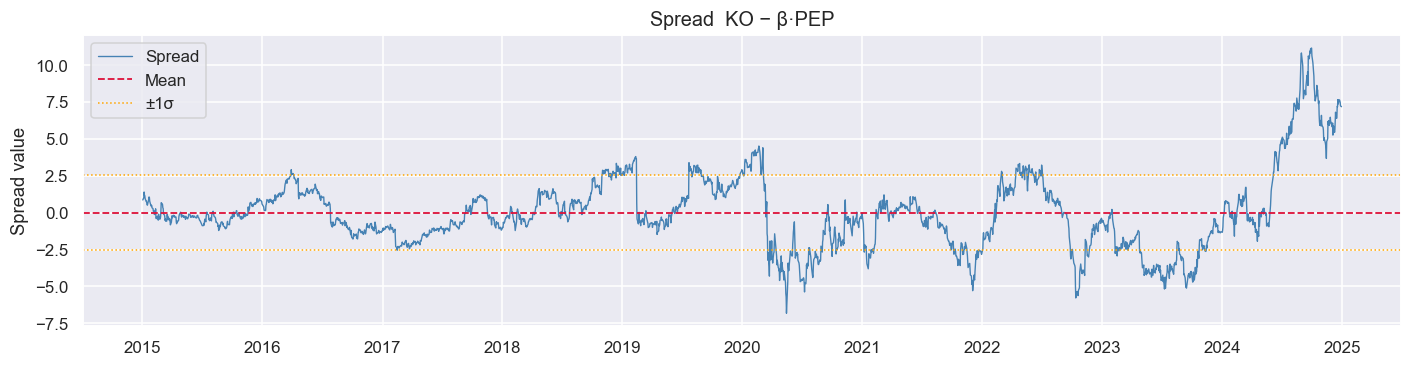

In [4]:
# ── 2d. Plot spread ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(spread.index, spread.values, lw=0.9, color='steelblue', label='Spread')
ax.axhline(spread.mean(), color='crimson', lw=1.2, ls='--', label='Mean')
ax.axhline(spread.mean() + spread.std(), color='orange', lw=1, ls=':', label='±1σ')
ax.axhline(spread.mean() - spread.std(), color='orange', lw=1, ls=':')
ax.set_title(f'Spread  {TICKER_A} − β·{TICKER_B}', fontsize=13)
ax.set_ylabel('Spread value')
ax.legend()
plt.tight_layout()
plt.show()

## 3  Fit the 3-regime Markov-Switching AR model

Each of the **3 hidden states** gets its own:
- AR coefficients  $\phi_1^{(k)}, \dots, \phi_p^{(k)}$
- Intercept / mean  $c^{(k)}$
- Innovation variance  $\sigma^{2(k)}$

The states will correspond (roughly) to **low / medium / high** spread levels — the model learns this from the data through the EM algorithm.

In [5]:
# ── 3a. Fit ──────────────────────────────────────────────────────────────────
model = MarkovAutoregression(
    spread,
    k_regimes=3,
    order=AR_ORDER,
    switching_ar=True,          # AR coefficients switch across regimes
    switching_variance=True,    # Variance switches across regimes
    switching_trend=True,       # Intercept switches across regimes
)

print('Fitting Markov-Switching AR model (EM algorithm) … this may take ~30 s …')
ms_result = model.fit(em_iter=200, search_reps=5, search_scale=0.5, disp=False)
print('Done.')
print(ms_result.summary())

c:\Users\lpset\anaconda3\envs\markov_spread\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Fitting Markov-Switching AR model (EM algorithm) … this may take ~30 s …


c:\Users\lpset\anaconda3\envs\markov_spread\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Done.
                         Markov Switching Model Results                         
Dep. Variable:                   spread   No. Observations:                 2513
Model:             MarkovAutoregression   Log Likelihood                -289.726
Date:                  Mon, 11 May 2026   AIC                            615.453
Time:                          15:47:06   BIC                            720.379
Sample:                               0   HQIC                           653.536
                                 - 2513                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4072      0.343     -4.101      0.000      -2.080      -0.735
sigma2         1.1581      0.3

In [6]:
# ── 3b. Extract parameters into a tidy structure ────────────────────────────
k = 3   # number of regimes
p = AR_ORDER

params = ms_result.params

# Helper: pull param by name-fragment for a given regime index
def get_param(name_fragment, regime_idx):
    """Find a parameter by searching for 'name_fragment[regime_idx]' in params index."""
    key = f'{name_fragment}[{regime_idx}]'
    if key in params.index:
        return params[key]
    # Fallback: try without regime suffix (shared param)
    if name_fragment in params.index:
        return params[name_fragment]
    raise KeyError(f'Parameter not found: {key}')

regime_params = []
for r in range(k):
    intercept = get_param('const', r)
    ar_coefs  = [get_param(f'ar.L{lag}', r) for lag in range(1, p + 1)]
    sigma2    = get_param('sigma2', r)
    regime_params.append({
        'intercept': intercept,
        'ar_coefs':  np.array(ar_coefs),
        'sigma':     np.sqrt(sigma2),
    })

# Transition matrix  P[i, j] = P(next state = j | current state = i)
# statsmodels stores it as (k, k) where trans[j, i] = P(t+1=j | t=i)
# → we transpose to get the row-stochastic convention
trans_raw = ms_result.regime_transition        # shape (k, k) or (k, k, 1)
if trans_raw.ndim == 3:
    trans_raw = trans_raw[:, :, 0]
P = trans_raw.T   # now P[i,j] = Prob(go to j | currently in i)

# ── Display ──────────────────────────────────────────────────────────────────
print('\n=== Regime Parameters ===')
for r, rp in enumerate(regime_params):
    print(f"\nRegime {r}:")
    print(f"  Intercept : {rp['intercept']:.4f}")
    for lag, c in enumerate(rp['ar_coefs'], 1):
        print(f"  AR lag {lag}   : {c:.4f}")
    print(f"  Sigma     : {rp['sigma']:.4f}")

print('\n=== Transition Matrix P[i→j] ===')
df_P = pd.DataFrame(P,
    index=[f'From R{i}' for i in range(k)],
    columns=[f'To R{j}' for j in range(k)])
print(df_P.round(4))


=== Regime Parameters ===

Regime 0:
  Intercept : -1.4072
  AR lag 1   : 0.5812
  AR lag 2   : -0.0367
  Sigma     : 1.0762

Regime 1:
  Intercept : -0.8113
  AR lag 1   : 0.9842
  AR lag 2   : 0.0106
  Sigma     : 0.4143

Regime 2:
  Intercept : -0.7115
  AR lag 1   : 0.9624
  AR lag 2   : 0.0314
  Sigma     : 0.1602

=== Transition Matrix P[i→j] ===
          To R0   To R1   To R2
From R0  0.6300  0.3576  0.0124
From R1  0.0109  0.9380  0.0512
From R2  0.0020  0.0366  0.9614


## 4  Label regimes as Low / Mid / High

We order regimes by their long-run mean $\mu^{(k)} = c^{(k)} / (1 - \sum \phi_l^{(k)})$ and assign **Low / Mid / High** labels.

In [7]:
# ── 4a. Compute long-run means and sort ──────────────────────────────────────
def long_run_mean(rp):
    """Long-run mean of an AR process: c / (1 - sum(phi))."""
    denom = 1.0 - rp['ar_coefs'].sum()
    if abs(denom) < 1e-6:
        return rp['intercept']  # near-unit-root: use intercept as proxy
    return rp['intercept'] / denom

lr_means = np.array([long_run_mean(rp) for rp in regime_params])
order    = np.argsort(lr_means)          # indices sorted low → high
labels   = ['Low', 'Mid', 'High']
regime_label = {order[i]: labels[i] for i in range(k)}

print('Regime → Label mapping (by long-run mean):')
for r in range(k):
    print(f'  Regime {r}  long-run mean = {lr_means[r]:+.4f}  →  {regime_label[r]}')

Regime → Label mapping (by long-run mean):
  Regime 0  long-run mean = -3.0893  →  High
  Regime 1  long-run mean = -157.0254  →  Low
  Regime 2  long-run mean = -115.1798  →  Mid


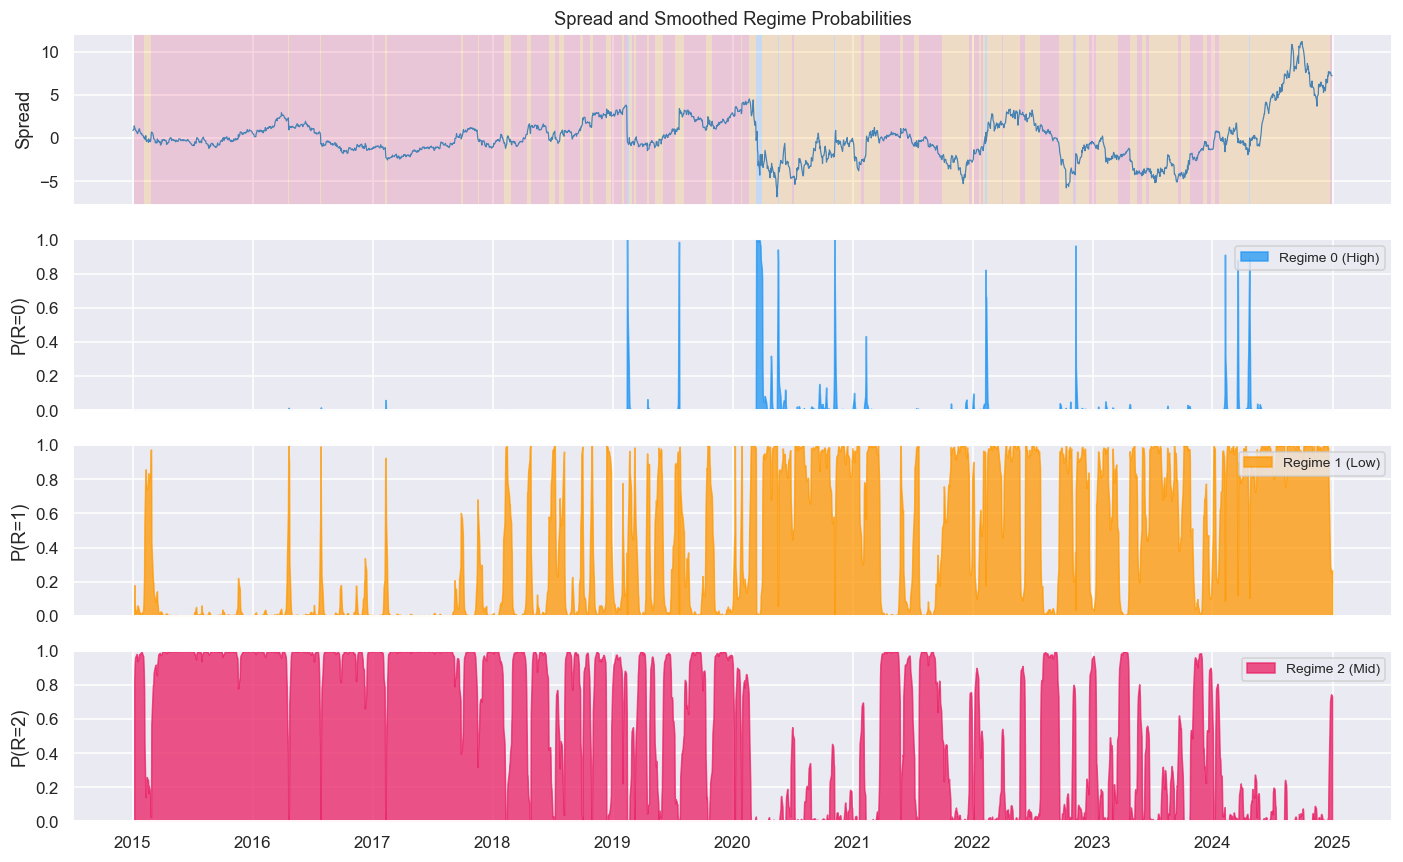

In [9]:
# ── 4b. Plot smoothed regime probabilities ───────────────────────────────────
smoothed = ms_result.smoothed_marginal_probabilities   # shape (T-p, k)

# Align the date index to the smoothed series (statsmodels drops first p obs)
smoothed_index = spread.index[len(spread) - len(smoothed):]   # ← add this

colors_regime = ['#2196F3', '#FF9800', '#E91E63']

fig, axes = plt.subplots(k + 1, 1, figsize=(13, 8), sharex=True)
axes[0].plot(spread.index, spread.values, lw=0.8, color='steelblue')
axes[0].set_ylabel('Spread')
axes[0].set_title('Spread and Smoothed Regime Probabilities')

dominant = np.argmax(smoothed.values, axis=1)
for t in range(len(dominant) - 1):                            # ← len(dominant) not len(spread)
    axes[0].axvspan(smoothed_index[t], smoothed_index[t+1],   # ← smoothed_index
                    alpha=0.18, color=colors_regime[dominant[t]], lw=0)

for r in range(k):
    axes[r + 1].fill_between(
        smoothed_index,                                        # ← smoothed_index
        smoothed.iloc[:, r].values,
        alpha=0.75,
        color=colors_regime[r],
        label=f'Regime {r} ({regime_label[r]})'
    )
    axes[r + 1].set_ylim(0, 1)
    axes[r + 1].set_ylabel(f'P(R={r})')
    axes[r + 1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

## 5  Simulate synthetic spread paths

Algorithm per path:
1. Sample initial regime from the stationary distribution of **P**
2. At each step $t$: draw the *next* regime from row $s_t$ of **P**
3. Generate:
   $$\text{spread}_t = c^{(s_t)} + \sum_{l=1}^{p} \phi_l^{(s_t)}\, \text{spread}_{t-l} + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,\, \sigma^{2(s_t)})$$
4. Discard the first `BURN_IN` steps.

In [10]:
# ── 5a. Stationary distribution of P ─────────────────────────────────────────
def stationary_dist(P):
    """Compute stationary distribution π such that π P = π."""
    k = P.shape[0]
    A = (P.T - np.eye(k))
    A[-1, :] = 1.0          # normalisation constraint
    b = np.zeros(k); b[-1] = 1.0
    return np.linalg.solve(A, b)

pi = stationary_dist(P)
print('Stationary distribution π =', np.round(pi, 4))

# ── 5b. Simulation function ──────────────────────────────────────────────────
def simulate_markov_ar(regime_params, P, pi, n_steps, burn_in=200, seed=None):
    """
    Simulate a spread path from the fitted Markov-Switching AR model.

    Parameters
    ----------
    regime_params : list of dict  (intercept, ar_coefs, sigma per regime)
    P             : (k, k) row-stochastic transition matrix
    pi            : (k,) stationary distribution
    n_steps       : int  — number of steps to *return* (after burn-in)
    burn_in       : int  — initial steps to discard
    seed          : int or None

    Returns
    -------
    spread_sim  : (n_steps,) array
    regimes_sim : (n_steps,) int array  — regime at each retained step
    """
    rng   = np.random.default_rng(seed)
    k     = len(regime_params)
    p     = len(regime_params[0]['ar_coefs'])
    total = n_steps + burn_in

    # Pre-allocate
    spread_all  = np.zeros(total + p)
    regimes_all = np.zeros(total, dtype=int)

    # Sample starting regime from stationary distribution
    state = rng.choice(k, p=pi)

    # Warm-start the lagged values near the unconditional spread mean
    spread_all[:p] = rng.normal(0, regime_params[state]['sigma'], size=p)

    cum_P = np.cumsum(P, axis=1)          # for fast row sampling

    for t in range(total):
        rp = regime_params[state]
        # AR contribution from lags
        lags       = spread_all[t: t + p][::-1]   # [t-1, t-2, …, t-p]
        ar_contrib = rp['ar_coefs'].dot(lags)
        noise      = rng.normal(0.0, rp['sigma'])
        spread_all[t + p] = rp['intercept'] + ar_contrib + noise
        regimes_all[t]    = state
        # Transition to next regime
        u     = rng.random()
        state = np.searchsorted(cum_P[state], u)

    return spread_all[p + burn_in:], regimes_all[burn_in:]


# ── 5c. Generate N_PATHS synthetic paths ────────────────────────────────────
sim_paths   = []
sim_regimes = []
for i in range(N_PATHS):
    s, r = simulate_markov_ar(regime_params, P, pi,
                               n_steps=N_STEPS, burn_in=BURN_IN, seed=i)
    sim_paths.append(s)
    sim_regimes.append(r)

print(f'Generated {N_PATHS} synthetic paths of length {N_STEPS} each.')

Stationary distribution π = [0.0154 0.4214 0.5632]
Generated 5 synthetic paths of length 504 each.


## 6  Visualise: original vs synthetic

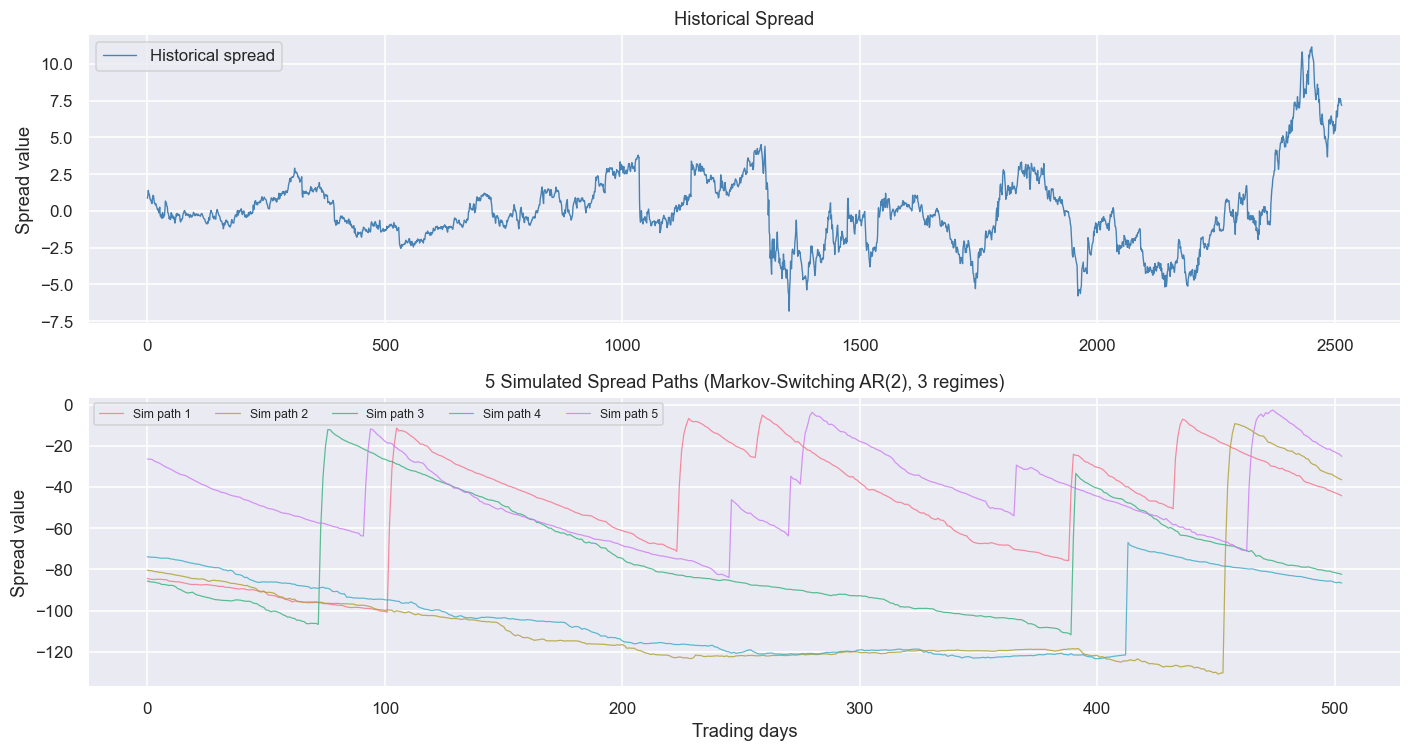

In [11]:
# ── 6a. Overlay synthetic paths on historical spread ─────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# Historical
axes[0].plot(spread.values, lw=0.9, color='steelblue', label='Historical spread')
axes[0].set_title('Historical Spread', fontsize=12)
axes[0].set_ylabel('Spread value')
axes[0].legend()

# Simulated
palette = sns.color_palette('husl', N_PATHS)
for i, path in enumerate(sim_paths):
    axes[1].plot(path, lw=0.8, alpha=0.8, color=palette[i], label=f'Sim path {i+1}')
axes[1].set_title(f'{N_PATHS} Simulated Spread Paths (Markov-Switching AR({AR_ORDER}), 3 regimes)', fontsize=12)
axes[1].set_ylabel('Spread value')
axes[1].set_xlabel('Trading days')
axes[1].legend(fontsize=8, ncol=N_PATHS)

plt.tight_layout()
plt.show()

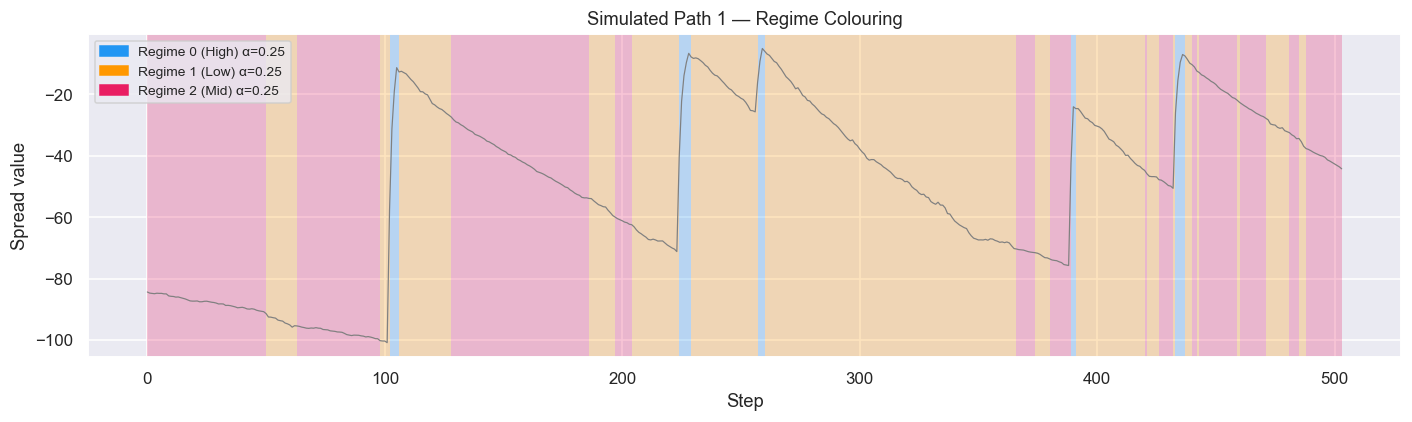

In [12]:
# ── 6b. Regime-coloured view of one simulated path ──────────────────────────
PATH_IDX = 0    # which path to show
path_show   = sim_paths[PATH_IDX]
regime_show = sim_regimes[PATH_IDX]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(path_show, lw=0.8, color='grey', zorder=2)

for t in range(len(path_show) - 1):
    ax.axvspan(t, t + 1, alpha=0.25, color=colors_regime[regime_show[t]], lw=0)

# Legend patches
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=colors_regime[r],
                           label=f'Regime {r} ({regime_label[r]}) α={0.25}')
           for r in range(k)]
ax.legend(handles=patches, fontsize=9)
ax.set_title(f'Simulated Path {PATH_IDX+1} — Regime Colouring', fontsize=12)
ax.set_xlabel('Step')
ax.set_ylabel('Spread value')
plt.tight_layout()
plt.show()

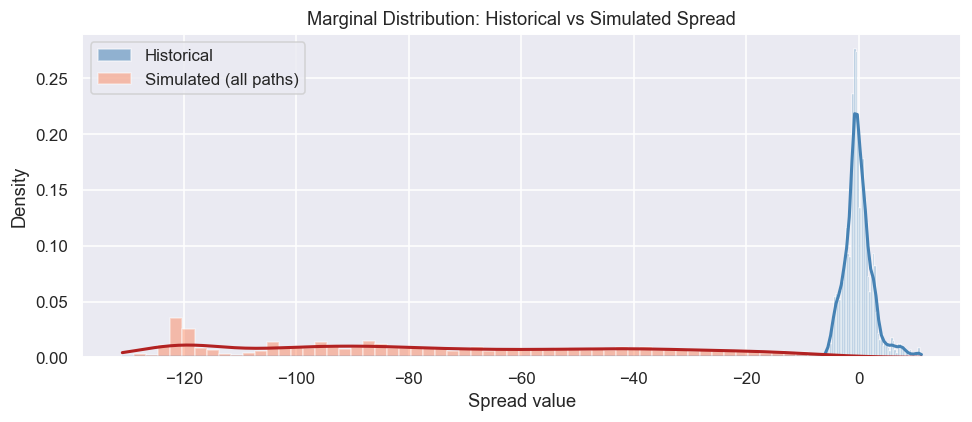

In [13]:
# ── 6c. Distribution comparison: historical vs all synthetic ─────────────────
all_sim = np.concatenate(sim_paths)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(spread.values, bins=60, density=True, alpha=0.55,
        color='steelblue', label='Historical')
ax.hist(all_sim, bins=60, density=True, alpha=0.45,
        color='coral', label='Simulated (all paths)')

# KDE curves
xs = np.linspace(min(spread.min(), all_sim.min()),
                 max(spread.max(), all_sim.max()), 300)
ax.plot(xs, stats.gaussian_kde(spread.values)(xs), 'steelblue', lw=2)
ax.plot(xs, stats.gaussian_kde(all_sim)(xs), 'firebrick', lw=2)
ax.set_title('Marginal Distribution: Historical vs Simulated Spread', fontsize=12)
ax.set_xlabel('Spread value')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

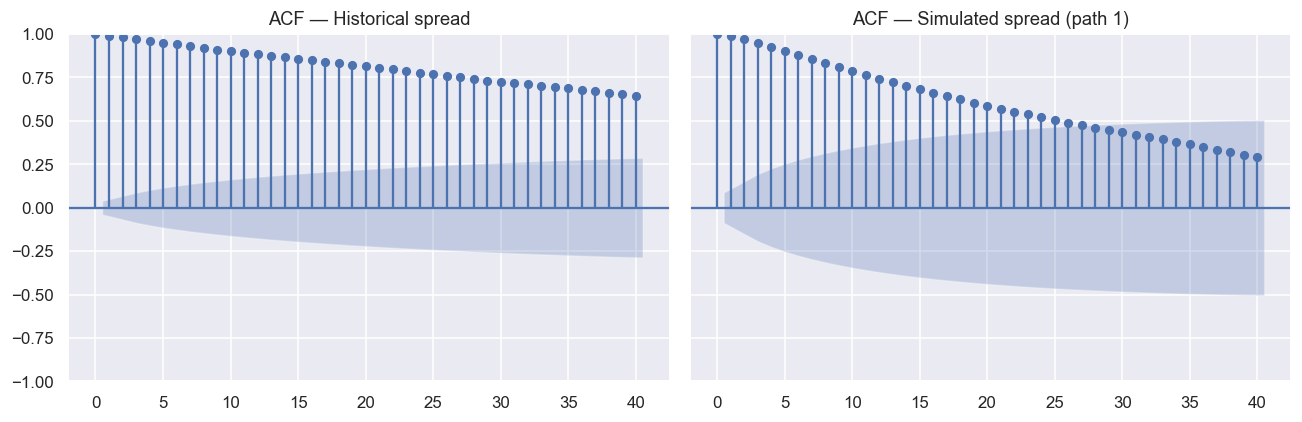

In [14]:
# ── 6d. ACF comparison ───────────────────────────────────────────────────────
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_acf(spread.values, lags=40, ax=axes[0], alpha=0.05,
         title='ACF — Historical spread')
plot_acf(sim_paths[0], lags=40, ax=axes[1], alpha=0.05,
         title='ACF — Simulated spread (path 1)')
plt.tight_layout()
plt.show()

In [15]:
# ── 6e. Summary statistics comparison ───────────────────────────────────────
stats_rows = []
series_dict = {'Historical': spread.values}
for i, path in enumerate(sim_paths):
    series_dict[f'Sim {i+1}'] = path

for name, values in series_dict.items():
    stats_rows.append({
        'Series': name,
        'Mean':   round(float(np.mean(values)), 4),
        'Std':    round(float(np.std(values)), 4),
        'Skew':   round(float(stats.skew(values)), 4),
        'Kurt':   round(float(stats.kurtosis(values)), 4),
        'Min':    round(float(np.min(values)), 4),
        'Max':    round(float(np.max(values)), 4),
    })

pd.DataFrame(stats_rows).set_index('Series')

,Mean,Std,Skew,Kurt,Min,Max
Series,,,,,,
Historical,-0.0000,2.5251,1.0022,2.4610,-6.8119,11.1570
Sim 1,-49.8545,27.3993,-0.3298,-1.0741,-100.8892,-5.0605
Sim 2,-103.2158,29.5130,1.9404,2.8957,-130.9144,-9.2108
Sim 3,-74.4838,25.0244,0.6533,-0.6112,-111.7656,-12.1099
Sim 4,-102.3021,17.8869,0.3269,-1.4405,-123.4109,-66.9638
Sim 5,-44.5400,19.1257,0.2662,-0.6491,-83.9660,-2.5682


## 7  Export synthetic data to CSV

In [16]:
# Build a DataFrame with one column per simulated path
sim_df = pd.DataFrame(
    np.column_stack(sim_paths),
    columns=[f'sim_path_{i+1}' for i in range(N_PATHS)]
)
sim_df.to_csv('simulated_spreads.csv', index=False)
print('Saved → simulated_spreads.csv')
sim_df.head()

Saved → simulated_spreads.csv


,sim_path_1,sim_path_2,sim_path_3,sim_path_4,sim_path_5
0,-84.383556,-80.438091,-85.631946,-73.872825,-26.404514
1,-84.743990,-80.566156,-86.013841,-74.045503,-26.415052
2,-84.849573,-80.715454,-86.142852,-74.065207,-26.582872
3,-84.940149,-81.084290,-86.256310,-74.161467,-27.395130
4,-84.784714,-81.160505,-86.555187,-74.226717,-27.871489


---
## Notes & next steps

| Topic | Details |
|---|---|
| **Pair selection** | Change `TICKER_A` / `TICKER_B` to any Yahoo Finance tickers |
| **AR order** | Tune `AR_ORDER` (1–3 typical) — use AIC/BIC from `ms_result.aic` |
| **Regime count** | Hardcoded to 3 here; generalises to any `k_regimes` |
| **Simulation length** | Adjust `N_STEPS` and `N_PATHS` freely |
| **Burn-in** | Increase `BURN_IN` if initial transients are visible |
| **Z-score spread** | Normalise `spread = (spread - spread.mean()) / spread.std()` for cleaner regimes |